In [3]:
import os 
import sys 

sys.path.append(os.path.abspath('../scripts'))
from db_connection import engine

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 



Load data frrom postgres

In [19]:
query =  """

SELECT

    CASE
        WHEN oi.freight_value < 20 THEN 'Low Freight'
        WHEN oi.freight_value < 50 THEN 'Medium Freight'
        ELSE 'High Freight'
    END AS freight_segment,

    COUNT(*) AS total_orders,

    ROUND(AVG(oi.freight_value)::numeric,2) AS avg_freight_value,
    ROUND(AVG(p.product_weight_g)::numeric,2) AS avg_product_weight_g,
    ROUND(AVG(DATE_PART('day',o.order_delivered_customer_date - o.order_purchase_timestamp))::numeric,2) 
	AS avg_delivery_days,

    ROUND(AVG(orv.review_score)::numeric,2) AS avg_review_score,
	
    ROUND(100.0 *
        COUNT(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 END)/
        NULLIF(COUNT(*),0),2) AS delay_rate

FROM orders o

LEFT JOIN order_items oi
    ON oi.order_id = o.order_id

LEFT JOIN products p
    ON p.product_id = oi.product_id

LEFT JOIN order_reviews orv
    ON orv.order_id = o.order_id

WHERE
    o.order_status = 'delivered'
    AND o.order_purchase_timestamp < '2018-09-02'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL

GROUP BY 1
ORDER BY avg_freight_value;

"""

delivery_df = pd.read_sql(query,engine)

delivery_df

,freight_segment,total_orders,avg_freight_value,avg_product_weight_g,avg_delivery_days,avg_review_score,delay_rate
0,Low Freight,80240,14.00,1102.90,10.73,4.11,7.23
1,Medium Freight,26090,28.46,3623.13,15.17,4.00,9.47
2,High Freight,4502,76.27,10743.84,16.67,3.96,10.73


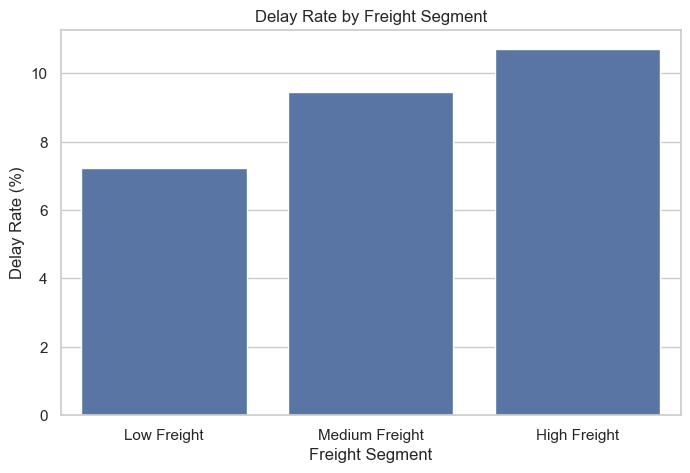

In [20]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(8,5))

sns.barplot(

    data=delivery_df,

    x='freight_segment',
    y='delay_rate'

)

plt.title('Delay Rate by Freight Segment')

plt.xlabel('Freight Segment')
plt.ylabel('Delay Rate (%)')

plt.show()

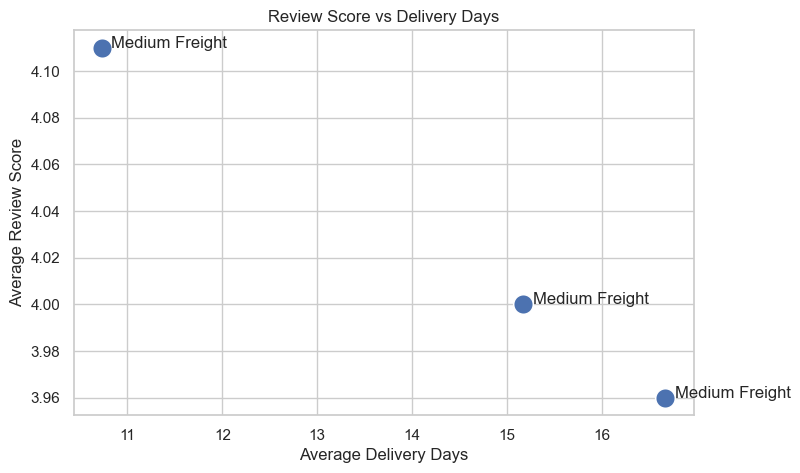

In [27]:
 # frieghtsegment vs review scores
sns.set_theme(style='whitegrid')

plt.figure(figsize=(8,5))

sns.scatterplot(
    data = delivery_df,

    x = 'avg_delivery_days',
    y = 'avg_review_score',
    s = 200

)

for i in range(len(delivery_df)):

    plt.text(
        delivery_df['avg_delivery_days'][i] + 0.1,
        delivery_df['avg_review_score'][i],
        delivery_df['freight_segment'][1]
    )

plt.title('Review Score vs Delivery Days')

plt.xlabel('Average Delivery Days')
plt.ylabel('Average Review Score')

plt.show()

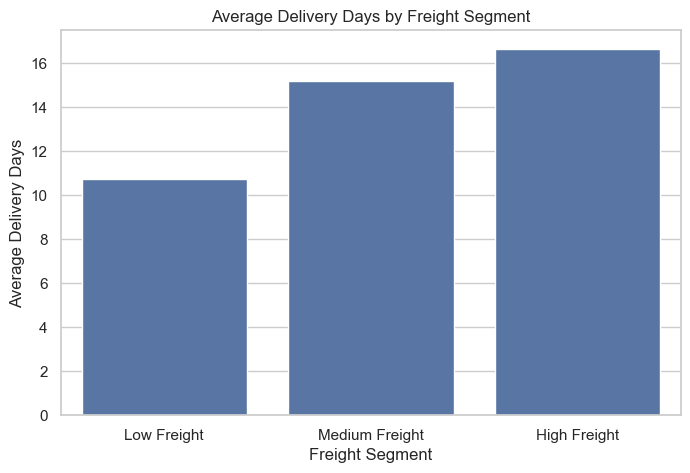

In [28]:
# delivery days by freight segment

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8,5))

sns.barplot(

    data=delivery_df,

    x='freight_segment',
    y='avg_delivery_days'

)

plt.title('Average Delivery Days by Freight Segment')

plt.xlabel('Freight Segment')
plt.ylabel('Average Delivery Days')

plt.show()